# Convergence of empirical $\mu_c$ to HDMFT as mean degree $C$ grows

The Heterogeneous DMFT prediction for the critical coupling $\mu_c$ depends on the *rescaled* degree distribution $\nu(g)$ with $g = k/C$. Here the degree sequence is exponential with scale $C$, so $g$ is exponential with mean 1 and $\nu(g)=e^{-g}$ is **fixed** — the theoretical $\mu_c$ does not depend on $C$.

The empirical estimate, however, comes from finite networks where mean-field is only approximate. This notebook sweeps $C$, and for each value builds `n_graphs` independent graph/weight realizations, fits the empirical $\mu_c$ on each via `glv.find_empirical_mu_c`, and plots the signed distance $\mu_c^{\mathrm{emp}} - \mu_c^{\mathrm{theory}}$ against $C$ with error bars (std over realizations). The distance is expected to shrink toward zero as $C$ grows and mean-field becomes exact.

Because the empirical transition drifts with $C$, the $\mu$ sweep for each $C$ is **recentred** on the previous $C$'s empirical $\mu_c$ (the first $C$ uses the theoretical value). This keeps the transition in the middle of the $\mu$ grid so the tanh fit is sampled on both plateaus and stays well-conditioned — otherwise the transition drifts toward the edge of a fixed window and the fitted midpoint scatters.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import multiprocessing as mp
import glv

glv.apply_style()

In [2]:
# --- Parameters ---
N        = 1000          # number of species (fixed across the sweep)
sigma    = 0.2           # std of interaction-strength fluctuations
C_values = [5, 10, 25, 50, 75, 100, 150]   # mean degrees to sweep
n_graphs = 10            # independent graph/weight realizations per C

n_mu     = 20            # mu grid points inside each find_empirical_mu_c fit
n_reps   = 3             # initial conditions per fit
tau_max  = 1e6           # rescaled-time integration horizon

n_outer_workers = 6      # processes for the outer (C, graph) sweep

# --- Theoretical mu_c (fixed: nu(g) = e^{-g}, independent of C) ---
nu_pdf = lambda g: np.exp(-g)
mu_c = glv.calculate_mu_c(sigma=sigma, gamma=0.0, nu_pdf=nu_pdf)["mu_c"]
print(f"mu_c (theoretical) = {mu_c:.4f}")

mu_c (theoretical) = 0.4990


In [3]:
def _job(args):
    """One (C, realization) job: build a fresh graph + weights, fit empirical mu_c.

    `mu_center` centres the mu sweep on a per-C estimate of the transition so
    the tanh fit stays well-conditioned. Returns (C, mu_emp - mu_c) or
    (C, None) if the tanh fit fails.
    """
    C, mu_center, seed = args
    rng = np.random.default_rng(seed)
    np.random.seed(seed % (2**32))  # seed global RNG used for weights in find_empirical_mu_c

    # Exponential degree sequence with mean C
    ds = np.maximum(rng.exponential(scale=C, size=N).astype(int), 1)
    if ds.sum() % 2 != 0:
        ds[0] += 1

    # Configuration-model graph, self-loops removed
    G = nx.Graph(nx.configuration_model(list(ds)))
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)

    # Initial conditions
    ics = []
    for _ in range(n_reps):
        x0 = rng.uniform(0.1, 1.0, N)
        M0 = float(x0.sum())
        ics.append(np.concatenate((x0 / M0, [M0], [0.0])))

    try:
        res = glv.find_empirical_mu_c(
            mu_c_theoretical=mu_c,
            A=A,
            C=C,
            sigma=sigma,
            initial_conditions=ics,
            n_mu=n_mu,
            mu_center=mu_center,
            tau_max=tau_max,
            method="RK45",
            n_workers=1,
        )
        return C, float(res["mu_c"] - mu_c)
    except RuntimeError:
        return C, None


# Sweep C in order; centre each C's mu window on the previous C's empirical
# mu_c so the (drifting) transition stays mid-grid and the tanh fit stays
# well-conditioned. The first C uses the theoretical value as the centre.
_seed_rng = np.random.default_rng(0)
deltas  = {C: [] for C in C_values}
centers = {}

ctx = mp.get_context("fork")
with ctx.Pool(processes=n_outer_workers) as pool:
    center = mu_c
    for C in C_values:
        centers[C] = center
        jobs_C = [(C, center, int(_seed_rng.integers(0, 2**31))) for _ in range(n_graphs)]
        for _, d in pool.map(_job, jobs_C):
            if d is not None:
                deltas[C].append(d)
        # Recentre the next C on this C's mean empirical mu_c
        if deltas[C]:
            center = mu_c + float(np.mean(deltas[C]))
        print(f"C={C:4d}:  {len(deltas[C])}/{n_graphs} successful fits  "
              f"(sweep centred at {centers[C]:.4f})")

/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:109: RuntimeWarning: invalid value encountered in divide
  return norm(self._estimate_error(K, h) / scale)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:109: RuntimeWarning: invalid value encountered in divide
  return norm(self._estimate_error(K, h) / scale)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-

C=   5:  9/10 successful fits  (sweep centred at 0.4990)
C=  10:  10/10 successful fits  (sweep centred at 0.4802)
C=  25:  10/10 successful fits  (sweep centred at 0.5068)
C=  50:  10/10 successful fits  (sweep centred at 0.5052)
C=  75:  10/10 successful fits  (sweep centred at 0.5943)
C= 100:  10/10 successful fits  (sweep centred at 0.6479)
C= 150:  10/10 successful fits  (sweep centred at 0.6858)


In [7]:
# --- Recompute C=25 in isolation ---
# C=25 showed anomalous scatter (std ~0.12 vs ~0.02 elsewhere), driven by a
# stray tanh fit. Recompute only its realizations, reusing the already-stored
# sweep centre `centers[25]` so the downstream C points (already computed off
# the old C=25 estimate) are left untouched. Fresh seeds -> new realizations.
C_fix = 25
_fix_rng = np.random.default_rng(2025)
jobs_fix = [(C_fix, centers[C_fix], int(_fix_rng.integers(0, 2**31)))
            for _ in range(n_graphs)]

with ctx.Pool(processes=n_outer_workers) as pool:
    results_fix = pool.map(_job, jobs_fix)

deltas[C_fix] = [d for _, d in results_fix if d is not None]

print(f"C={C_fix}: {len(deltas[C_fix])}/{n_graphs} successful fits  "
      f"(sweep centred at {centers[C_fix]:.4f})")
for i, d in enumerate(deltas[C_fix]):
    print(f"  graph {i}:  mu_emp - mu_c = {d:+.4f}")
print(f"  mean = {np.mean(deltas[C_fix]):+.4f}  +/- {np.std(deltas[C_fix]):.4f}")

/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)
/Users/ludovicofurlanetto/Code/glv/glv/analysis.py:176: RuntimeWarning: Mean of empty slice
  mean_t = np.nanmean(t_mat, axis=1)
/Users/ludovicofurlanetto/Code/glv/glv/analysis.py:176: RuntimeWarning: Mean of empty slice
  mean_t = np.nanmean(t_mat, axis=1)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:64: RuntimeWarning: overflow encountered in add
  K[s] = fun(t + c * h, y + dy)
/Users/ludovicofurlanetto/Code/glv/glv/analysis.py:176: RuntimeWarning: Mean of empty slice
  mean_t = np.nanmean(t_mat, axis=1)
/Users/ludovicofurlanetto/Code/glv/.venv/lib/python3.14/site-packages/scipy/integr

C=25: 10/10 successful fits  (sweep centred at 0.5068)
  graph 0:  mu_emp - mu_c = +0.0191
  graph 1:  mu_emp - mu_c = +0.0840
  graph 2:  mu_emp - mu_c = +0.0199
  graph 3:  mu_emp - mu_c = +0.0203
  graph 4:  mu_emp - mu_c = +0.0269
  graph 5:  mu_emp - mu_c = +0.0123
  graph 6:  mu_emp - mu_c = +0.0443
  graph 7:  mu_emp - mu_c = +0.0309
  graph 8:  mu_emp - mu_c = +0.0923
  graph 9:  mu_emp - mu_c = +0.0555
  mean = +0.0405  +/- 0.0268


In [8]:
# --- Aggregate: mean and std of the signed distance per C ---
C_arr    = np.array([C for C in C_values if len(deltas[C]) > 0], dtype=float)
mean_d   = np.array([np.mean(deltas[C]) for C in C_values if len(deltas[C]) > 0])
std_d    = np.array([np.std(deltas[C])  for C in C_values if len(deltas[C]) > 0])

for C, m, s in zip(C_arr, mean_d, std_d):
    print(f"C={C:6.0f}:  mean(mu_emp - mu_c) = {m:+.4f}  +/- {s:.4f}")

C=     5:  mean(mu_emp - mu_c) = -0.0188  +/- 0.0194
C=    10:  mean(mu_emp - mu_c) = +0.0078  +/- 0.0308
C=    25:  mean(mu_emp - mu_c) = +0.0405  +/- 0.0268
C=    50:  mean(mu_emp - mu_c) = +0.0953  +/- 0.0199
C=    75:  mean(mu_emp - mu_c) = +0.1489  +/- 0.0241
C=   100:  mean(mu_emp - mu_c) = +0.1868  +/- 0.0166
C=   150:  mean(mu_emp - mu_c) = +0.2669  +/- 0.0215


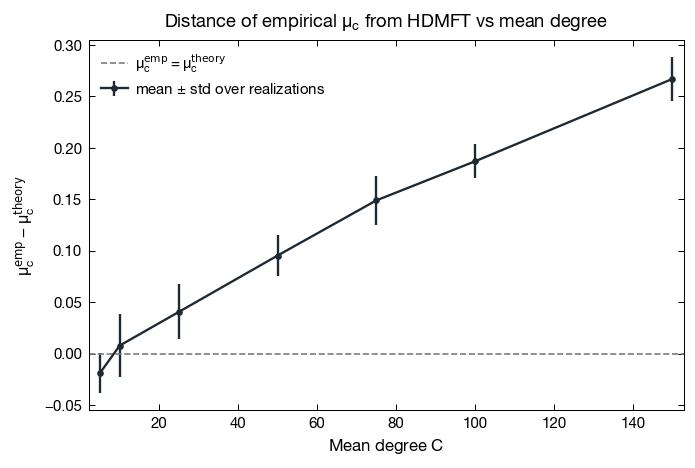

In [9]:
fig, ax = plt.subplots()

ax.errorbar(
    C_arr, mean_d, yerr=std_d,
    marker="o", linestyle="-", capsize=2.5,
    label=r"mean $\pm$ std over realizations",
)
ax.axhline(0.0, color="#7a7d83", linestyle="--", linewidth=1.0,
           label=r"$\mu_c^{\mathrm{emp}} = \mu_c^{\mathrm{theory}}$")

ax.set_xlabel(r"Mean degree $C$")
ax.set_ylabel(r"$\mu_c^{\mathrm{emp}} - \mu_c^{\mathrm{theory}}$")
ax.set_title(r"Distance of empirical $\mu_c$ from HDMFT vs mean degree")
ax.legend()

plt.show()